# day 27 prep

We are now ready to handle 2nd order differential equations. The method will be similar to coupled first order equations because that is exactly how we will treat any second order equation: as a set of coupled first order equations like below.

Let's take an example second order equation and look at the technique. We will take a mass on a spring under damped conditions:

$$ ma = -c v - k x$$

The first thing we want to do is put this in terms of all of the derivative:

$$m\frac{d^2 x}{dt^2} = -c\frac{dx}{dt} - k x $$

Then we want to isolate the second derivative. 

$$\frac{d^2 x}{dt^2} = -\frac{c}{m}\frac{dx}{dt} - \frac{k}{m} x $$

Then we want to break this up into two first order differential equations. And this looks a little bit backwards, but we need to realize that we just replaced \$v$ with \$\frac{dx}{dt}$ so what if we went backwards that in terms of the substitution of variables.

$$\frac{d v}{dt} = -\frac{c}{m} v - \frac{k}{m} x $$

and then 

$$ \frac{dx}{dt} = v$$

So now we can run this exactly the same way that we did coupled first order equations, because that is what they are! And we can choose almost any kind of differential equation that we want to. To start off with we may just choose an object falling from some height. The initial height is an important initial value and the fact that we are dropping it is important since the initial velocity will be equal to zero.

$$a = -g\ =>\  \frac{d^2x}{dt^2}\ =>\ \frac{dv}{dt} = -g \quad \mbox{and} \quad \frac{dx}{dt} = v $$

And this same logic can be applied to other sets, so we could cover linear drag:

$$\frac{dv}{dt} = -g - \frac{c}{m} v \quad \mathrm{and} \quad \frac{dx}{dt} = v $$

Or we can do quadratic drag but you do have to be more careful since the signs are more tricky:

$$\frac{dv}{dt} = -g + \frac{c}{m} v^2 \quad \mathrm{and} \quad \frac{dx}{dt} = v$$

For this case you have to watch out for the *SIGNS* of the velocity because they are squared and there is not an easy way to handle them if the object comes to rest and changes direction.

In [1]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt

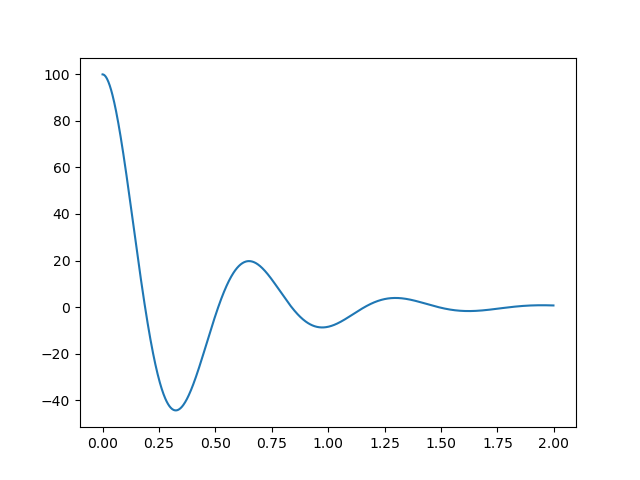

In [20]:
# Runge-Kutta 4nd order

def f(r,t):
    x = r[0]
    v = r[1]
    c = 5
    m = 1
    k = 100
    fx = v
    fv = -c/m*v - k/m*x
    return(np.array([fx,fv],float))

# define boundary conditions

t0 = 0.0 # starting point
tf = 2.0 # ending point
N = 1000 # number of points between a and b
dt = (tf-t0)/N

r = np.array([100,0],float) # initial condition

tpoints = np.arange(t0, tf, dt)
xpoints = []
vpoints = []

for t in tpoints:
    xpoints.append(r[0])
    vpoints.append(r[1])
    k1 = dt*f(r,t)
    k2 = dt*f(r+0.5*k1,t+0.5*dt)
    k3 = dt*f(r+0.5*k2,t+0.5*dt)
    k4 = dt*f(r+k3, t+dt)
    r = r + (k1+2*k2+2*k3+k4)/6

fig0, ax0 = plt.subplots()
ax0.plot(tpoints, xpoints)
#ax0.plot(tpoints, vpoints)